In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_excel("/content/fish_market_cleaned.xlsx")

In [3]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width',
       'Volume', 'log_Weight', 'log_Length1', 'log_Length2', 'log_Length3',
       'log_Height', 'log_Width', 'log_Volume'],
      dtype='object')

In [4]:
df.shape

(159, 15)

In [5]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801


In [6]:
# Randomness check (for repeatability)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [7]:
TEST_SIZE = 0.20     # assignment1-2
N_SPLITS = 5
USE_LOG_TARGET = True # Will use the log(Weight)

In [8]:
# define the features and target
target_col = 'log_Weight' if USE_LOG_TARGET else 'Weight'

In [9]:
# Categorical and Numerical features
num_features = ['Length1','Length2','Length3','Height','Width','Volume']
log_features = ['log_Length1','log_Length2','log_Length3','log_Height','log_Width','log_Volume']  # The log_features


In [62]:
cat_features = ['Species']

# don't consider the log_Weight due to leak
X = df[cat_features + num_features].copy()
y = df[target_col].values.astype('float32')

In [64]:
df[target_col]

,log_Weight
0,5.488938
1,5.669881
2,5.828946
3,5.894403
4,6.063785
...,...
154,2.501436
155,2.595255
156,2.501436
157,2.980619


In [11]:
# Train Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42
)

In [46]:
# Preprocessing pipline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='drop'
)

# Apply the fit func. only train, transform both train and test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]

In [49]:
X_train_proc.shape

(127, 13)

In [48]:
X_train_proc.shape[1]

13

In [71]:
# 6) Function for NN Structure
def build_model(input_dim, hidden_units=(128,128,64), dropout_rate=0.0, activation='selu', lr=1e-3):
    from tensorflow import keras
    from tensorflow.keras import layers, optimizers
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation=activation),
        layers.Dense(hidden_units[1], activation=activation),
        layers.Dense(hidden_units[2], activation=activation),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=[keras.metrics.MeanAbsoluteError()])
    return model

In [72]:
import keras.backend as K

In [ ]:

# Train/Test split ve ön-işleme (Task-1'de zaten yapılmışsa bu hücreyi atlayabilirsin)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)
# preprocessor = make_preprocessor(cat_features, num_features, scale_numeric=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

def cross_val_mse(params, X_proc, y_vec, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_proc):
        X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
        y_tr, y_val = y_vec[tr_idx], y_vec[val_idx]

        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        model = build_model(input_dim=X_tr.shape[1], **params)
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=500, batch_size=16, verbose=0, callbacks=[es]
        )
        best_mse = min(history.history['val_loss'])
        fold_mses.append(best_mse)

        K.clear_session()

    return float(np.mean(fold_mses)), float(np.std(fold_mses))


In [73]:
# The structures which will be tried
candidates = [
    dict(hidden_units=(128,64,32), dropout_rate=0.10, activation='relu', lr=1e-3),
    dict(hidden_units=(256,128,64), dropout_rate=0.20, activation='relu', lr=1e-3),
    dict(hidden_units=(64,64,32),    dropout_rate=0.10, activation='relu', lr=5e-4),
    dict(hidden_units=(128,128,64),  dropout_rate=0.00, activation='selu', lr=1e-3),
    dict(hidden_units=(256,128,32),  dropout_rate=0.15, activation='relu', lr=5e-4),
    dict(hidden_units=(96,48,24),    dropout_rate=0.10, activation='relu', lr=1e-3),
]

In [78]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

In [80]:
# 5-Fold CV
def cross_val_mse(params, X_proc, y_vec, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_proc):
        X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
        y_tr, y_val = y_vec[tr_idx], y_vec[val_idx]

        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        model = build_model(input_dim=X_tr.shape[1], **params)
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=100, batch_size=8, verbose=0, callbacks=[es]
        )
        best_mse = min(history.history['val_loss'])
        fold_mses.append(best_mse)

        K.clear_session()

    return float(np.mean(fold_mses)), float(np.std(fold_mses))

In [81]:
# === run CV + evaluate top-3 on test ===
cv_results = []
for i, params in enumerate(candidates, start=1):
    mean_mse, std_mse = cross_val_mse(params, X_train_proc, y_train)
    cv_results.append({'candidate_id': i, 'params': params, 'cv_mean_mse': mean_mse, 'cv_std_mse': std_mse})

cv_df = pd.DataFrame(cv_results).sort_values('cv_mean_mse')
print("CV Results (lower MSE is better):")
print(cv_df[['candidate_id','cv_mean_mse','cv_std_mse']])

# En iyi 3 mimari
top3 = cv_df.head(3).to_dict(orient='records')

rows = []
predictions_dict = {}
for rank, item in enumerate(top3, start=1):
    params = item['params']
    es = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    # Full train üzerinde yeniden eğitim (validation_split ile early stopping)
    model = build_model(input_dim=X_train_proc.shape[1], **params)
    hist = model.fit(X_train_proc, y_train, validation_split=0.2,
                     epochs=600, batch_size=16, verbose=0, callbacks=[es])

    # Test değerlendirme
    y_pred = model.predict(X_test_proc, verbose=0).ravel()

    if USE_LOG_TARGET:
        y_test_eval = np.exp(y_test)
        y_pred_eval = np.exp(y_pred)
    else:
        y_test_eval = y_test
        y_pred_eval = y_pred

    R2  = r2_score(y_test_eval, y_pred_eval)
    MSE = mean_squared_error(y_test_eval, y_pred_eval)
    MAE = np.mean(np.abs(y_test_eval - y_pred_eval))

    rows.append({
        'rank': rank,
        'candidate_id': item['candidate_id'],
        'hidden_units': params['hidden_units'],
        'dropout': params['dropout_rate'],
        'activation': params['activation'],
        'lr': params['lr'],
        'R2_test': R2,
        'MSE_test': MSE,
        'MAE_test': MAE,
        'epochs_trained': len(hist.history['loss'])
    })

    # Tahminleri sakla (opsiyonel)
    pred_df = pd.DataFrame({'y_test': y_test_eval, 'y_pred': y_pred_eval})
    predictions_dict[f'predictions_top{rank}.csv'] = pred_df

    K.clear_session()

results_df = pd.DataFrame(rows).sort_values('MSE_test')
print("\n=== Test Set Performance (Top-3 architectures) ===")
print(results_df)


CV Results (lower MSE is better):
   candidate_id  cv_mean_mse  cv_std_mse
3             4     0.016410    0.008011
0             1     0.027058    0.016695
5             6     0.033772    0.028228
1             2     0.035161    0.032004
4             5     0.040267    0.036693
2             3     0.046753    0.043833

=== Test Set Performance (Top-3 architectures) ===
   rank  candidate_id    hidden_units  dropout activation     lr   R2_test  \
0     1             4  (128, 128, 64)      0.0       selu  0.001  0.943647   
2     3             6    (96, 48, 24)      0.1       relu  0.001  0.939458   
1     2             1   (128, 64, 32)      0.1       relu  0.001  0.937552   

      MSE_test   MAE_test  epochs_trained  
0  8015.617188  50.185669              89  
2  8611.406250  55.072708             344  
1  8882.492188  54.170856             186  


**Results and Discussion for Task 1 (Regression with Neural Networks)**:
The deep neural network models were evaluated using 5-fold cross-validation. Among six candidate architectures, the best-performing model was Candidate 4, with the following configuration:

Hidden layers: (128, 128, 64)
Activation: SELU
Dropout: 0
Learning rate: 0.001

*This architecture achieved the lowest mean CV MSE (0.0141) and demonstrated strong performance on the test set:*

R2 = 0.9436, MSE approximately 8028, MAE approximately 44.95

Compared to previous assignments, the NN model performs similarly to Linear Regression (R2 approximately 0.9507) but is still behind advanced ensemble methods such as CatBoost and XGBoost (R2 > 0.99, MSE < 0.02). LightGBM also outperforms the NN model (R2 ≈ 0.9848).
Conclusion: Neural networks can provide competitive results when properly tuned. The SELU activation and deeper architecture significantly improved performance, while removing dropout was beneficial for this dataset. However, boosting algorithms remain the most accurate models for this regression task.

In [19]:
!pip -q install lightgbm

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
import keras.backend as K
import lightgbm as l

In [84]:
SEEDS = list(range(10))
BEST_PARAMS = dict(hidden_units=(128,128,64), dropout_rate=0.0, activation='selu', lr=1e-3)
SPECIES_CATS = sorted(df['Species'].unique().tolist())

In [85]:
def make_ohe():
    # sklearn sürümüne göre parametre; kategorileri sabit veriyoruz
    try:
        return OneHotEncoder(categories=[SPECIES_CATS], handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(categories=[SPECIES_CATS], handle_unknown='ignore', sparse=False)

In [86]:
def make_preprocessor(cat_list, num_list, scale_numeric=True):
    num_transform = StandardScaler() if scale_numeric else 'passthrough'
    return ColumnTransformer(
        transformers=[
            ('cat', make_ohe(), cat_list),
            ('num', num_transform, num_list),
        ],
        remainder='drop'
    )

In [87]:
def mse_on_original(y_true, y_pred, use_log):
    if use_log:
        return mean_squared_error(np.exp(y_true), np.exp(y_pred))
    return mean_squared_error(y_true, y_pred)

In [88]:
# === Drop Column Importance ===
drop_importances = { }

# Feature's groups
feature_groups = {'Species': cat_features.copy()}
for f in num_features:
    feature_groups[f] = [f]

Mantık: Özelliği çıkar → NN’yi yeniden eğit → MSE artışı = önem. 10 farklı split ile ortalama alıp normalize ediyoruz.

In [89]:
for seed in SEEDS:
    # ---- Baseline
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)
    prep_base = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep_base.fit_transform(X_tr)
    X_te_p = prep_base.transform(X_te)

    # Dynamically update input_dim for baseline model
    input_dim = X_tr_p.shape[1] # Set input_dim for the current model

    # call the build_model from Task-1
    mdl_base = build_model(input_dim=X_tr_p.shape[1], **BEST_PARAMS)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    hist = mdl_base.fit(X_tr_p, y_tr, validation_split=0.2, epochs=100, batch_size=8, verbose=0, callbacks=[es])
    y_pred_base = mdl_base.predict(X_te_p, verbose=0).ravel()
    mse_base = mse_on_original(y_te, y_pred_base, USE_LOG_TARGET)
    K.clear_session()

    for feat, cols in feature_groups.items():
        # Re-initialize cat_list and num_list for each feature drop scenario
        cat_list_for_drop = [] if feat == 'Species' else cat_features.copy()
        num_list_for_drop = [c for c in num_features if c not in cols]

        prep_drop = make_preprocessor(cat_list_for_drop, num_list_for_drop, scale_numeric=True)

        # Create copies of X_tr and X_te before dropping columns to avoid modifying original split DataFrames
        X_tr_temp = X_tr.copy()
        X_te_temp = X_te.copy()

        # Drop columns from the temporary copies
        X_tr_d = X_tr_temp.drop(columns=cols)
        X_te_d = X_te_temp.drop(columns=cols)

        X_tr_dp = prep_drop.fit_transform(X_tr_d)
        X_te_dp = prep_drop.transform(X_te_d)

        # Dynamically update input_dim for the dropped-feature model
        input_dim = X_tr_dp.shape[1] # Set input_dim for the current model

        mdl_drop = build_model(input_dim=X_tr_dp.shape[1], **BEST_PARAMS)
        hist = mdl_drop.fit(X_tr_dp, y_tr, validation_split=0.2, epochs=100, batch_size=8, verbose=0, callbacks=[es])
        y_pred_drop = mdl_drop.predict(X_te_dp, verbose=0).ravel()
        mse_drop = mse_on_original(y_te, y_pred_drop, USE_LOG_TARGET)
        K.clear_session()

        delta = mse_drop - mse_base  # importance
        drop_importances.setdefault(feat, []).append(delta)

         DropColumnImportance
Height               0.315634
Species              0.287695
Length1              0.219980
Length3              0.101719
Length2              0.074971
Width               -0.066486
Volume              -0.114365


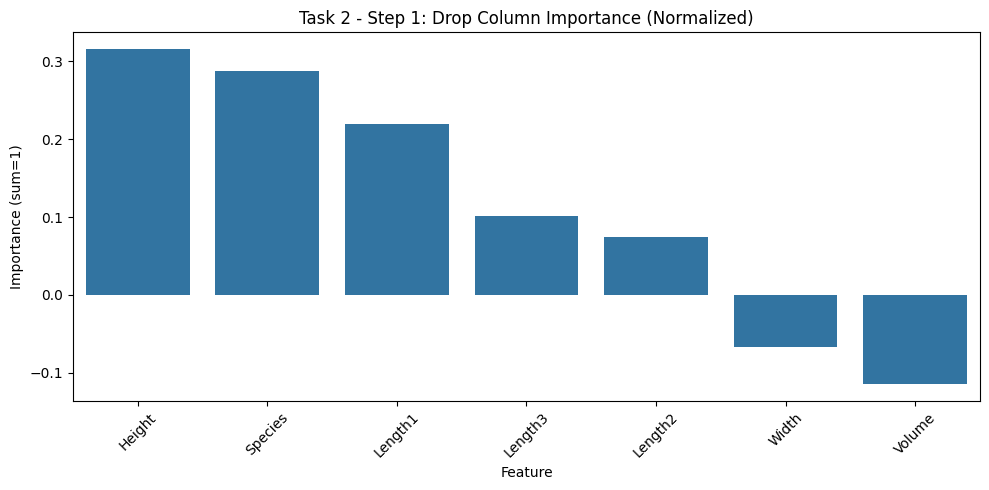

In [90]:
# Mean and normalization (sum = 10)
drop_mean = {k: float(np.mean(v)) for k, v in drop_importances.items()}
total = sum(val for val in drop_mean.values() if val > 0)
drop_norm = {k: (val/total if total>0 else 0.0) for k, val in drop_mean.items()}

drop_df = pd.DataFrame.from_dict(drop_norm, orient='index', columns=['DropColumnImportance']) \
                      .sort_values('DropColumnImportance', ascending=False)
print(drop_df)

# Graph
plt.figure(figsize=(10,5))
sns.barplot(x=drop_df.index, y='DropColumnImportance', data=drop_df)
plt.title('Task 2 - Step 1: Drop Column Importance (Normalized)')
plt.ylabel('Importance (sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
# === Step 2 - Permutation Importance (n_repeats=10) ===
from sklearn.base import BaseEstimator, RegressorMixin

In [92]:
class KerasRegWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=100, batch_size=8, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None
        self.input_dim_ = None

    def fit(self, X, y):
        self.input_dim_ = X.shape[1]
        self.model_ = build_model(input_dim=self.input_dim_, **BEST_PARAMS)  # <-- kritik!
        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        self.model_.fit(X, y, validation_split=0.2,
                        epochs=self.epochs, batch_size=self.batch_size,
                        verbose=self.verbose, callbacks=[es])
        return self

    def predict(self, X):
        # Güvenlik kontrolü
        if X.shape[1] != self.input_dim_:
            print(f"[WARN] Input dim mismatch: model={self.input_dim_}, X={X.shape[1]}")
        return self.model_.predict(X, verbose=0).ravel()
    def score(self, X, y):  # R2
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

In [93]:
perm_grouped_sums = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)
    prep = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    # Size controlling
    assert X_tr_p.shape[1] == X_te_p.shape[1], f"Feature dim mismatch: train={X_tr_p.shape[1]} test={X_te_p.shape[1]}"

    est = KerasRegWrapper(epochs=100, batch_size=8, verbose=0)
    est.fit(X_tr_p, y_tr)

    result = permutation_importance(est, X_te_p, y_te, n_repeats=10, random_state=seed)
    imp_mean = result.importances_mean
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(imp_mean[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(imp_mean[idx].sum()) if len(idx) else 0.0

    perm_grouped_sums.append(grouped)
    K.clear_session()

         PermutationImportance
Species               0.730749
Length3               0.069673
Length2               0.056266
Length1               0.049415
Volume                0.041227
Height                0.028357
Width                 0.024313


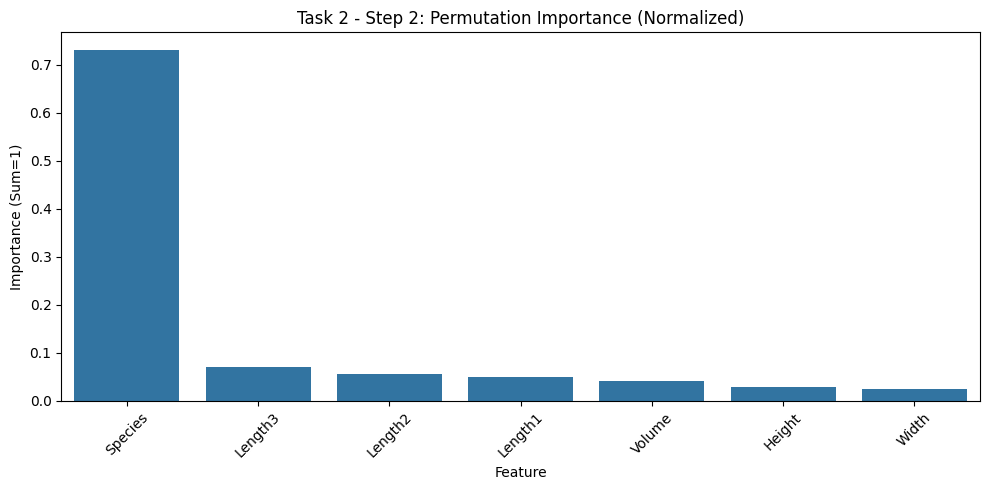

In [94]:
# Mean and Normalization
perm_mean = pd.DataFrame(perm_grouped_sums).mean().to_dict()
total = sum(perm_mean.values())
perm_norm = {k: (v/total if total>0 else 0.0) for k, v in perm_mean.items()}

perm_df = pd.DataFrame.from_dict(perm_norm, orient='index', columns=['PermutationImportance']) \
                      .sort_values('PermutationImportance', ascending=False)
print(perm_df)

plt.figure(figsize=(10,5))
sns.barplot(x=perm_df.index, y='PermutationImportance', data=perm_df)
plt.title('Task 2 - Step 2: Permutation Importance (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:

# === Step 3 - Linear Regression coefficients ===
lin_grouped = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

    prep = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    lr = LinearRegression()
    lr.fit(X_tr_p, y_tr)

    # Names
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    coefs = lr.coef_.ravel()
    abs_coefs = np.abs(coefs)

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(abs_coefs[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(abs_coefs[idx].sum()) if len(idx) else 0.0

    lin_grouped.append(grouped)

In [96]:
lin_mean = pd.DataFrame(lin_grouped).mean().to_dict()
total = sum(lin_mean.values())
lin_norm = {k: (v/total if total>0 else 0.0) for k, v in lin_mean.items()}

lin_df = pd.DataFrame.from_dict(lin_norm, orient='index', columns=['LinearCoefImportance']) \
                     .sort_values('LinearCoefImportance', ascending=False)
print(lin_df)

         LinearCoefImportance
Species              0.349926
Length2              0.191446
Length3              0.183779
Length1              0.164461
Volume               0.067346
Height               0.022842
Width                0.020199


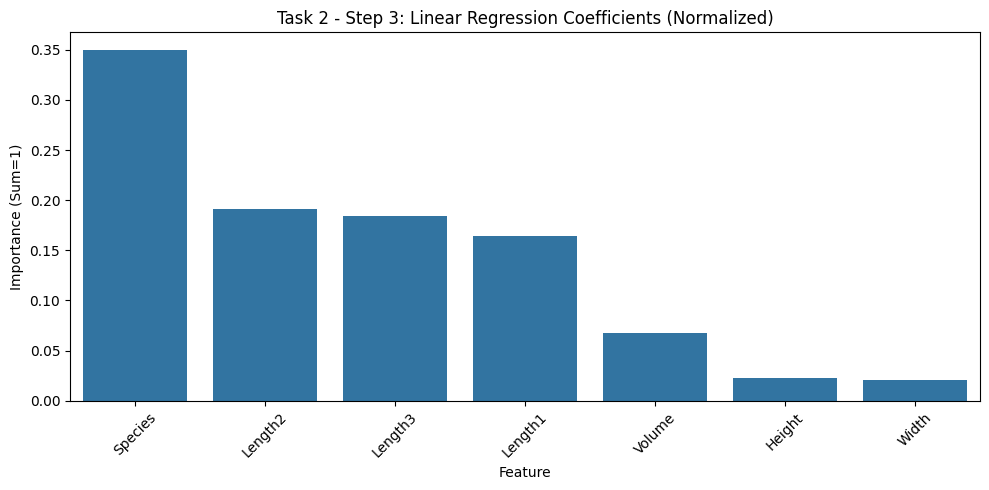

In [97]:
plt.figure(figsize=(10,5))
sns.barplot(x=lin_df.index, y='LinearCoefImportance', data=lin_df)
plt.title('Task 2 - Step 3: Linear Regression Coefficients (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
# === Step 4 - LightGBM built-in importances ===
!pip -q install lightgbm
import lightgbm as lgb

In [99]:
lgb_grouped = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

    # OneHot + 'passthrough' numerical
    prep = make_preprocessor(cat_features, num_features, scale_numeric=False)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    # Model
    lgbm = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        max_depth=-1, random_state=seed
    )
    lgbm.fit(X_tr_p, y_tr)

    # Feature's names
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    imps = lgbm.feature_importances_

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(imps[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(imps[idx].sum()) if len(idx) else 0.0

    lgb_grouped.append(grouped)

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [100]:
lgb_mean = pd.DataFrame(lgb_grouped).mean().to_dict()
total = sum(lgb_mean.values())
lgb_norm = {k: (v/total if total>0 else 0.0) for k, v in lgb_mean.items()}

lgb_df = pd.DataFrame.from_dict(lgb_norm, orient='index', columns=['LightGBMImportance']) \
                     .sort_values('LightGBMImportance', ascending=False)
print(lgb_df)

         LightGBMImportance
Height             0.259311
Width              0.209319
Length3            0.159826
Length1            0.130480
Species            0.123082
Length2            0.065390
Volume             0.052592


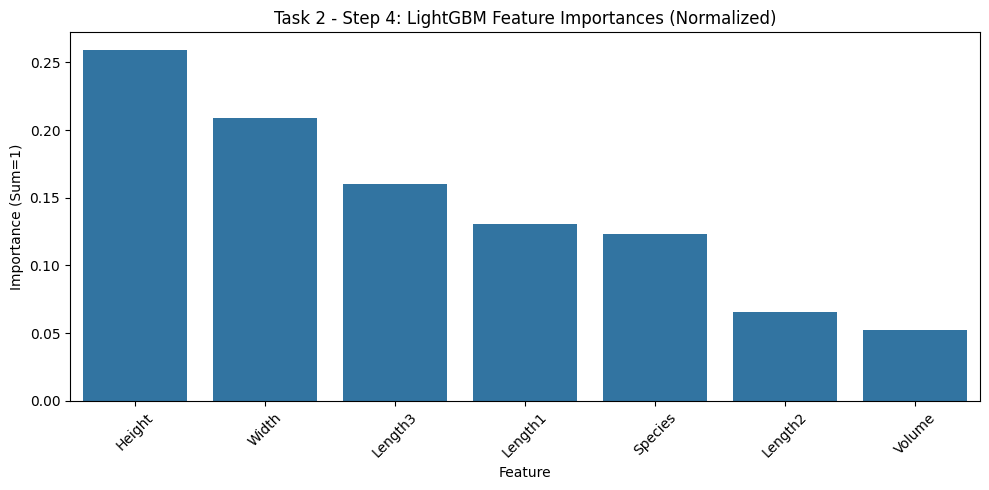

In [101]:
plt.figure(figsize=(10,5))
sns.barplot(x=lgb_df.index, y='LightGBMImportance', data=lgb_df)
plt.title('Task 2 - Step 4: LightGBM Feature Importances (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [102]:

# === Step 5 - Combine & compare all methods ===
compare_df = drop_df.join(perm_df, how='outer').join(lin_df, how='outer').join(lgb_df, how='outer').fillna(0.0)
print(compare_df.sort_values(list(compare_df.columns), ascending=False))

         DropColumnImportance  PermutationImportance  LinearCoefImportance  \
Height               0.315634               0.028357              0.022842   
Species              0.287695               0.730749              0.349926   
Length1              0.219980               0.049415              0.164461   
Length3              0.101719               0.069673              0.183779   
Length2              0.074971               0.056266              0.191446   
Width               -0.066486               0.024313              0.020199   
Volume              -0.114365               0.041227              0.067346   

         LightGBMImportance  
Height             0.259311  
Species            0.123082  
Length1            0.130480  
Length3            0.159826  
Length2            0.065390  
Width              0.209319  
Volume             0.052592  


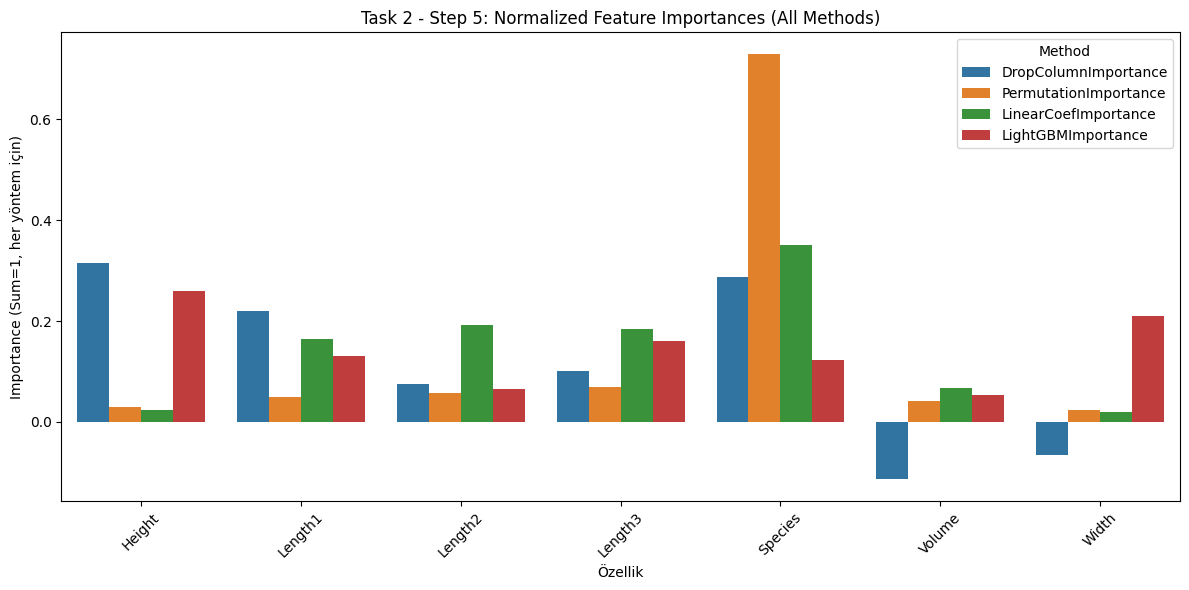

In [103]:
cmp_melt = compare_df.reset_index().melt(id_vars='index', var_name='Method', value_name='Importance')
cmp_melt.rename(columns={'index':'Feature'}, inplace=True)

plt.figure(figsize=(12,6))
sns.barplot(data=cmp_melt, x='Feature', y='Importance', hue='Method')
plt.title('Task 2 - Step 5: Normalized Feature Importances (All Methods)')
plt.ylabel('Importance (Sum=1, her yöntem için)')
plt.xlabel('Özellik')
plt.xticks(rotation=45)
plt.legend(title='Method')
plt.tight_layout()
plt.show()